In [ ]:
!pip install -q ultralytics pycocotools tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 7.5 MB/s eta 0:00:00


In [ ]:
!wget -q http://images.cocodataset.org/zips/val2017.zip
!wget -q http://images.cocodataset.org/annotations/annotations_trainval2017.zip

!unzip -q val2017.zip
!unzip -q annotations_trainval2017.zip

In [ ]:
import os
import shutil
from pycocotools.coco import COCO

ann_file = "/content/annotations/instances_val2017.json"
coco = COCO(ann_file)

# COCO category IDs
target_classes = {
    1: 0,    # person -> YOLO class 0
    16: 1,   # bird -> YOLO class 1
    18: 2    # dog -> YOLO class 2
}

os.makedirs("/content/dataset/images", exist_ok=True)
os.makedirs("/content/dataset/labels", exist_ok=True)

img_ids = set()

for cat_id in target_classes:
    ids = coco.getImgIds(catIds=[cat_id])[:50]
    img_ids.update(ids)

print("Images found:", len(img_ids))

loading annotations into memory...
Done (t=1.42s)
creating index...
index created!
Images found: 148


In [ ]:
from tqdm import tqdm

for img_id in tqdm(img_ids):
    img = coco.loadImgs(img_id)[0]

    src = f"/content/val2017/{img['file_name']}"
    dst = f"/content/dataset/images/{img['file_name']}"

    if not os.path.exists(src):
        continue

    shutil.copy(src, dst)

    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)

    label_file = dst.replace("/images/", "/labels/")
    label_file = label_file.replace(".jpg", ".txt")

    lines = []

    for ann in anns:
        cat = ann["category_id"]

        if cat not in target_classes:
            continue

        x, y, w, h = ann["bbox"]

        img_w = img["width"]
        img_h = img["height"]

        x_center = (x + w/2) / img_w
        y_center = (y + h/2) / img_h

        w /= img_w
        h /= img_h

        cls = target_classes[cat]

        lines.append(
            f"{cls} {x_center} {y_center} {w} {h}"
        )

    with open(label_file, "w") as f:
        f.write("\n".join(lines))

100%|██████████| 148/148 [00:00<00:00, 1484.18it/s]


In [ ]:
import random

images = os.listdir("/content/dataset/images")
random.shuffle(images)

split = int(0.8 * len(images))

train_imgs = images[:split]
valid_imgs = images[split:]

for folder in [
    "train/images",
    "train/labels",
    "valid/images",
    "valid/labels"
]:
    os.makedirs(f"/content/dataset/{folder}", exist_ok=True)

for img in train_imgs:
    shutil.move(
        f"/content/dataset/images/{img}",
        f"/content/dataset/train/images/{img}"
    )

    shutil.move(
        f"/content/dataset/labels/{img.replace('.jpg','.txt')}",
        f"/content/dataset/train/labels/{img.replace('.jpg','.txt')}"
    )

for img in valid_imgs:
    shutil.move(
        f"/content/dataset/images/{img}",
        f"/content/dataset/valid/images/{img}"
    )

    shutil.move(
        f"/content/dataset/labels/{img.replace('.jpg','.txt')}",
        f"/content/dataset/valid/labels/{img.replace('.jpg','.txt')}"
    )

In [ ]:
%%writefile /content/dataset/data.yaml
path: /content/dataset

train: train/images
val: valid/images

names:
  0: person
  1: bird
  2: dog

Writing /content/dataset/data.yaml


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/dataset/data.yaml",
    epochs=10,
    imgsz=416,
    batch=4,
    device="cpu"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7927c6762ff0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [ ]:
model = YOLO("runs/detect/train/weights/best.pt")

results = model.predict(
    source="/content/test.jpg",
    conf=0.25
)


image 1/1 /content/test.jpg: 416x256 1 person, 167.1ms
Speed: 3.3ms preprocess, 167.1ms inference, 2.1ms postprocess per image at shape (1, 3, 416, 256)


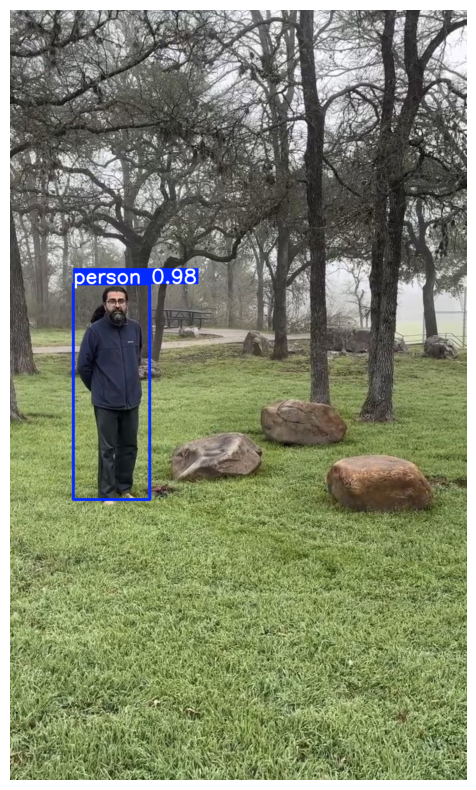

In [ ]:
import cv2
import matplotlib.pyplot as plt

for r in results:
    img = cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10,10))
    plt.imshow(img)
    plt.axis("off")
    plt.show()